In [1]:
ENV["PYTHONPATH"] = "/home/gridsan/aligho/.local/lib/python3.8/site-packages/PyNormaliz-2.15-py3.8-linux-x86_64.egg";

In [2]:
using DelimitedFiles, PyPlot, LinearAlgebra
using Crystalline, Brillouin, MPBUtils, SymmetryBases, JLD2
using Crystalline: TEST_αβγs, TEST_αβγ, dot, norm
topology_paper_dir = "../../TopologyPaper/"
include(topology_paper_dir * "get-freqs-symeigs.jl")
include(topology_paper_dir * "symeigs-from-io.jl");

In [3]:
io = open("dispersion.log")
logstr = read(io, String)
close(io)
dispersion_str = logs_to_dispersion(logstr, "");
dispersion = readdlm(IOBuffer(dispersion_str), ',')[:, 6:end]
kpts = readdlm(IOBuffer(dispersion_str), ',')[:, 2:4];

In [4]:
X_point_idxs = findall(x-> isapprox(x, 0), [norm([0.5, 0, 0] .- collect(row)) for row in eachrow(kpts)])
M_point_idxs = findall(x-> isapprox(x, 0), [norm([0.5, 0.5, 0] .- collect(row)) for row in eachrow(kpts)])
Gamma_point_idxs = findall(x-> isapprox(x, 0), [norm([0, 0, 0] .- collect(row)) for row in eachrow(kpts)])
R_point_idxs = findall(x-> isapprox(x, 0), [norm([0.5, 0.5, 0.5] .- collect(row)) for row in eachrow(kpts)]);

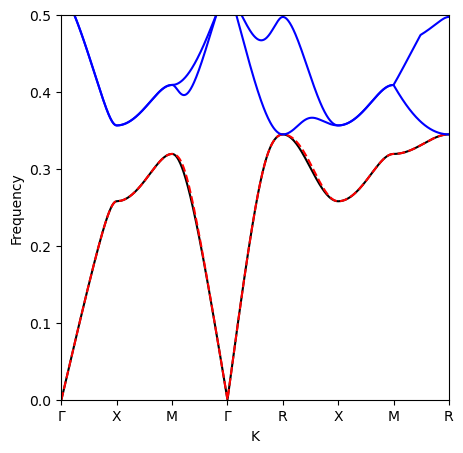

In [6]:
figure(figsize=(5, 5))
plot(1:first(size(dispersion)), dispersion[:, 1], color="black")
plot(1:first(size(dispersion)), dispersion[:, 2], color="red", linestyle="dashed")
plot(1:first(size(dispersion)), dispersion[:, 3], color="blue")
plot(1:first(size(dispersion)), dispersion[:, 4], color="blue")

xlim(1, first(size(dispersion)))
xticks([Gamma_point_idxs..., X_point_idxs..., R_point_idxs..., M_point_idxs...], [repeat(["Γ"], length(Gamma_point_idxs))...,
        repeat(["X"], length(X_point_idxs))..., repeat(["R"], length(R_point_idxs))...,  repeat(["M"], length(M_point_idxs))...])
ylim(0, 0.5)
ylabel("Frequency")
xlabel("K");

# Now we plot the dispersion with the DOS on the RHS

In [9]:
dos_dir = "../fig_dos/"
loaded_dos = load(dos_dir * "dos.jld2")
dos, energies = loaded_dos["dos"], loaded_dos["energies"];

In [22]:
### Sanity check the dos: 
@assert isapprox(100 * sum(diff(energies)[1] * dos[1:end-1])/5, 100, atol=0.5)

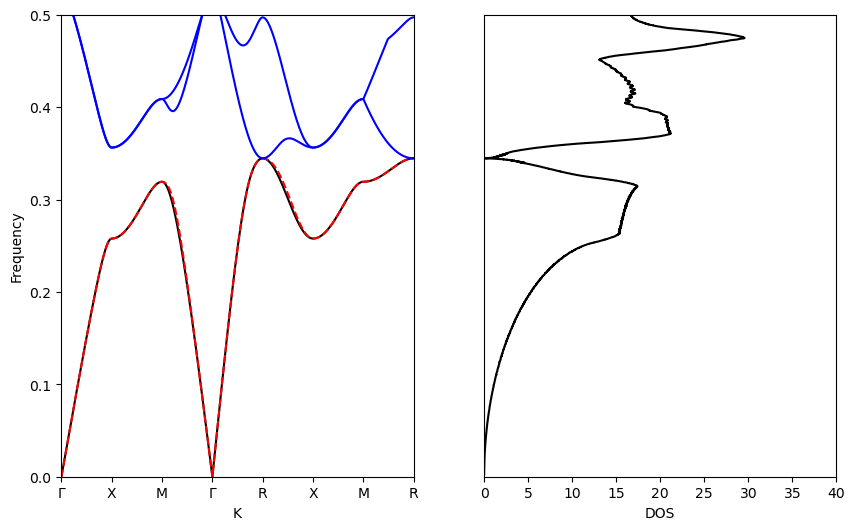

In [12]:
figure(figsize=(10, 6))
subplot(1, 2, 1)
plot(1:first(size(dispersion)), dispersion[:, 1], color="black")
plot(1:first(size(dispersion)), dispersion[:, 2], color="red", linestyle="dashed")
plot(1:first(size(dispersion)), dispersion[:, 3], color="blue")
plot(1:first(size(dispersion)), dispersion[:, 4], color="blue")

xlim(1, first(size(dispersion)))
xticks([Gamma_point_idxs..., X_point_idxs..., R_point_idxs..., M_point_idxs...], [repeat(["Γ"], length(Gamma_point_idxs))...,
        repeat(["X"], length(X_point_idxs))..., repeat(["R"], length(R_point_idxs))...,  repeat(["M"], length(M_point_idxs))...])
ylim(0, 0.5)
ylabel("Frequency")
xlabel("K");
subplot(1, 2, 2)
plot(dos, energies, color="black")
ylim(0, 0.5)
xlabel("DOS")
yticks([])
xlim(0, 40);
#savefig("Bands_with_DOS.pdf")

### Below, we show the Brillouin zone 

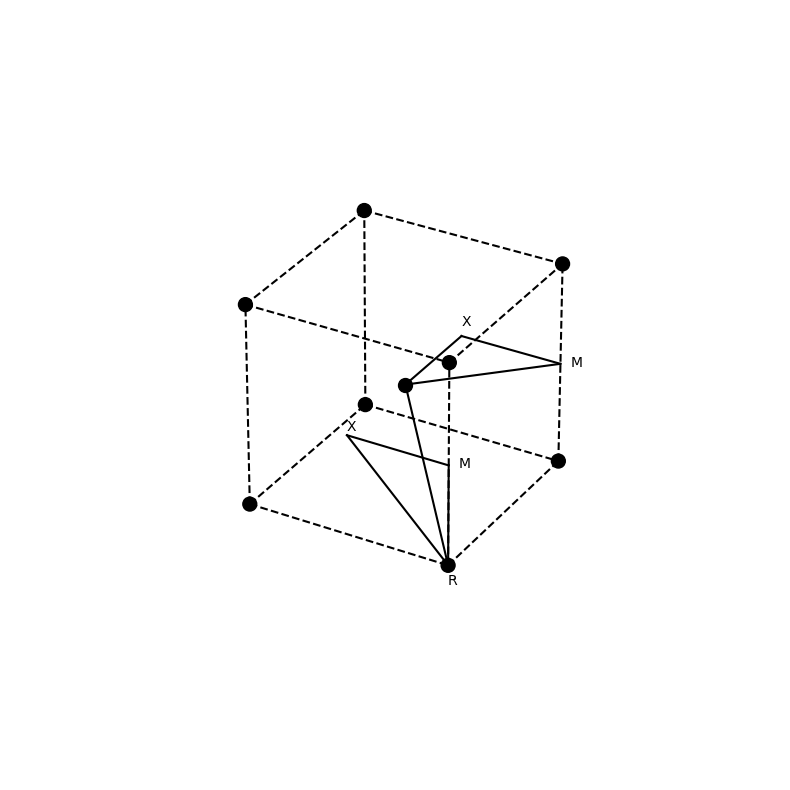

In [14]:
using PyPlot
figure(figsize=(10, 10))
subplot(projection="3d")
min_lim = -1
max_lim = 1

coords = [[-0.5, -0.5, -0.5] + [i, j, k]  for i in 0:1 for j in 0:1 for k in 0:1]

gca().scatter([c[1] for c in coords], [c[2] for c in coords], [c[3] for c in coords], s=100, color="black", alpha=1)
gca().scatter([0], [0], [0], s=100, color="black", alpha=1)
xlim(min_lim, max_lim)
ylim(min_lim, max_lim)
zlim(min_lim, max_lim)

ls1 = "solid"
ls2 = "dashed"

gca().xaxis.set_pane_color((0, 0, 0, 0))  # X-axis pane
gca().yaxis.set_pane_color((0, 0, 0, 0))  # Y-axis pane
gca().zaxis.set_pane_color((0, 0, 0, 0))  # Z-axis pane
gca().grid(false)
xticks([])
yticks([])
zticks([])
gca().xaxis.line.set_color((0, 0, 0, 0))  # Hide X-axis line
gca().yaxis.line.set_color((0, 0, 0, 0))  # Hide Y-axis line
gca().zaxis.line.set_color((0, 0, 0, 0))  # Hide Z-axis line

gca().plot([-0.5, -0.5], [-0.5, -0.5], [-0.5, 0.5], color="black",linestyle=ls2)
gca().plot([0.5, 0.5], [-0.5, -0.5], [-0.5, 0.5], color="black",linestyle=ls2)
gca().plot([-0.5, -0.5], [0.5, 0.5], [-0.5, 0.5], color="black",linestyle=ls2)
gca().plot([0.5, 0.5], [0.5, 0.5], [-0.5, 0.5], color="black",linestyle=ls2)

gca().plot([-0.5, -0.5], [-0.5, 0.5], [-0.5, -0.5], color="black",linestyle=ls2)
gca().plot([-0.5, -0.5], [-0.5, 0.5], [0.5, 0.5], color="black",linestyle=ls2)
gca().plot([0.5, 0.5], [-0.5, 0.5], [-0.5, -0.5], color="black",linestyle=ls2)
gca().plot([0.5, 0.5], [-0.5, 0.5], [0.5, 0.5], color="black",linestyle=ls2)

gca().plot([-0.5, 0.5], [-0.5, -0.5], [-0.5, -0.5], color="black",linestyle=ls2)
gca().plot([-0.5, 0.5], [0.5, 0.5], [0.5, 0.5], color="black",linestyle=ls2)
gca().plot([-0.5, 0.5], [-0.5, -0.5], [0.5, 0.5], color="black",linestyle=ls2)
gca().plot([-0.5, 0.5], [0.5, 0.5], [-0.5, -0.5], color="black",linestyle=ls2)

gca().plot([0, 0], [0, 0.5], [0, 0], color="black", linestyle=ls1)
gca().plot([0, 0.5], [0.5, 0.5], [0, 0], color="black", linestyle=ls1)
gca().plot([0.5, 0], [0.5, 0], [0, 0], color="black", linestyle=ls1)

gca().plot([0, 0.5], [0, -0.5], [0, -0.5], color="black", linestyle=ls1)
gca().plot([0.5, 0], [-0.5, -0.5], [-0.5, 0], color="black",linestyle=ls1)
gca().plot([0, 0.5], [-0.5, -0.5], [0, 0], color="black", linestyle=ls1)
gca().plot([0.5, 0.5], [-0.5, -0.5], [0, -0.5], color="black", linestyle=ls1)


gca().set_aspect("equal")

gca().text(0, 0.5, 0.05, "X")
gca().text(0.55, 0.5, 0, "M")
gca().text(0.5, -0.5, -0.6, "R")
gca().text(0, -0.5, 0.02, "X")
gca().text(0.55, -0.5, 0, "M");

#plt.savefig("BzonePath.pdf")